# Computer Exercise 4.1 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 4.1 Polynomial Interpolation — *Lagrange form · Newton divided differences*
> **풀이 일자**: Day 103
> **언어**: Python 3 (NumPy / pandas / Matplotlib)

---

Day 68–102 (Ch 15) 를 닫고 **교재 본문으로 복귀하는 첫 문제**다. Day 102 가 남긴 문장 —
*문제가 나쁜 조건이면 알고리즘을 아무리 다듬어도 소용없다* — 이 §4.1 에서 **두 겹**으로
되풀이된다. 오늘 Problem 1 은 그중 **표현(representation) 층**을 본다: 같은 다항식을 세 가지
형식으로 쓰면 수학적으로는 하나지만 **비용과 안정성은 전혀 다르다.** 그리고 그 과정에서
*세 형식이 다 같이 무너지는* 두 번째 층 — 절점 배치 — 이 얼굴을 내민다. 그것이 Problem 2 다.

## 1. 문제 (원문)

> **Computer Exercise 4.1.1.** Write and test routines that construct the polynomial $p$ of degree
> at most $n$ interpolating $f$ at $n+1$ distinct nodes $x_0,\dots,x_n$, in each of three
> representations:
>
> (a) the **Lagrange form** $p(x)=\sum_{i=0}^{n} f(x_i)\,\ell_i(x)$, both evaluated directly and via
> the barycentric formula;
> (b) the **Newton form** $p(x)=\sum_{k=0}^{n} f[x_0,\dots,x_k]\prod_{j<k}(x-x_j)$, with the
> divided differences computed by the standard triangular recurrence and the polynomial evaluated
> by nested (Horner) multiplication;
> (c) the **monomial form** $p(x)=\sum_{k=0}^{n} a_k x^k$, with the coefficients $a_k$ obtained by
> solving the Vandermonde system.
>
> Verify numerically that all three produce the *same* polynomial, as the uniqueness theorem
> requires, and account for whatever discrepancy you observe. Count the arithmetic operations
> needed to (i) construct each representation and (ii) evaluate it at $m$ points. Show that adding
> one new node to an existing Newton interpolant costs $O(n)$ operations whereas the barycentric
> weights must be rebuilt in $O(n^2)$. Finally, verify the identity
> $f[x_0,\dots,x_n]=f^{(n)}(\xi)/n!$ for $f(x)=e^{x}$, and examine the effect of rounding on the
> divided-difference table by comparing against exact rational arithmetic.

### 한국어 풀이용 정리

서로 다른 절점 $x_0,\dots,x_n$ 과 값 $f(x_i)$ 가 주어졌을 때 차수 $\le n$ 인 보간다항식은
**유일**하다. 그러나 그 유일한 다항식을 **적어 두는 방법**은 여럿이고, 방법마다 다음이 다르다.

| 항목 | Lagrange 직접 | 무게중심 | Newton | 단항식(Vandermonde) |
|---|---|---|---|---|
| 구성 비용 | — | $O(n^2)$ | $O(n^2)$ | $O(n^3)$ |
| 1 점 평가 | $O(n^2)$ | $O(n)$ | $O(n)$ | $O(n)$ |
| 절점 1 개 추가 | — | $O(n^2)$ 재구성 | $\mathbf{O(n)}$ | $O(n^3)$ 재구성 |

이 표를 **말이 아니라 측정으로** 채우는 것이 오늘의 과제다. 덧붙여
$f[x_0,\dots,x_n]=f^{(n)}(\xi)/n!$ 를 확인하고, 나눗셈차분표가 **소거(cancellation)** 에 얼마나
취약한지를 유리수 정확산술과 대조해 잰다 (Day 102 P3 (a) 의 직접적 후속).

## 2. 수학적 배경

### 2.1 존재와 유일성

**정리.** $x_0,\dots,x_n$ 이 서로 다르면, 임의의 값 $y_0,\dots,y_n$ 에 대해 $p(x_i)=y_i$ 를
만족하는 차수 $\le n$ 의 다항식 $p$ 가 **정확히 하나** 존재한다.

*증명 스케치.* 존재는 Lagrange 구성이 준다. 유일성은 두 해의 차 $q=p_1-p_2$ 가 차수 $\le n$ 인데
$n+1$ 개의 근을 가지므로 $q\equiv 0$ 이라는 데서 나온다. $\blacksquare$

따라서 아래 네 형식은 **같은 함수**를 다르게 적은 것에 불과하고, 형식 사이의 평가값 차이는
**전부 반올림 오차**다. 그 크기를 재는 것이 [2] 의 목적이다.

### 2.2 Lagrange 형식과 무게중심(barycentric) 형식

$$\ell_i(x)=\prod_{j\ne i}\frac{x-x_j}{x_i-x_j},\qquad p(x)=\sum_{i=0}^{n} y_i\,\ell_i(x).$$

직접 평가하면 한 점당 $O(n^2)$ 이다. **무게** $w_i=\bigl[\prod_{j\ne i}(x_i-x_j)\bigr]^{-1}$ 를
한 번 ($O(n^2)$) 계산해 두면 **제2형 무게중심 공식**

$$\boxed{\;p(x)=\Bigl.\sum_{i}\frac{w_i}{x-x_i}\,y_i \Bigm/ \sum_{i}\frac{w_i}{x-x_i}\;}$$

로 한 점당 $O(n)$ 이 된다. 이 형식은 **후방안정**하다는 것이 알려져 있다 (Higham 2004).

### 2.3 Newton 형식과 나눗셈차분

$$f[x_i]=f(x_i),\qquad
f[x_i,\dots,x_{i+k}]=\frac{f[x_{i+1},\dots,x_{i+k}]-f[x_i,\dots,x_{i+k-1}]}{x_{i+k}-x_i}$$

$$p(x)=\sum_{k=0}^{n} f[x_0,\dots,x_k]\,\pi_k(x),\qquad \pi_k(x)=\prod_{j=0}^{k-1}(x-x_j).$$

중첩 곱셈으로 한 점당 $O(n)$. **증분성** — 절점 $x_{n+1}$ 을 붙일 때 기존 계수
$c_0,\dots,c_n$ 은 그대로 남고 $c_{n+1}$ 하나만 추가된다:

$$c_{n+1}=f[x_0,\dots,x_{n+1}]=\frac{y_{n+1}-p_n(x_{n+1})}{\prod_{j=0}^{n}(x_{n+1}-x_j)}.$$

### 2.4 나눗셈차분과 도함수

**정리.** $f\in C^{n}[a,b]$, $x_0,\dots,x_n\in[a,b]$ 가 서로 다르면 어떤
$\xi\in(\min x_i,\max x_i)$ 가 있어

$$\boxed{\;f[x_0,\dots,x_n]=\frac{f^{(n)}(\xi)}{n!}\;}$$

이 식이 §4.2 의 보간오차 정리로 곧장 이어진다 (Day 104 의 주제).

### 2.5 두 개의 조건수 — 계수의 조건과 **값**의 조건

이 노트북에서 구별해야 할 두 양이 있다.

* **$\kappa_2(V)$** — Vandermonde 행렬 $V_{ik}=x_i^{\,k}$ 의 조건수. **단항식 계수** $a_k$ 가
  얼마나 흔들리는지를 지배한다. 등간격 절점에서 $n$ 에 지수적으로 커진다 (Gautschi 1975).
* **Lebesgue 상수** $\displaystyle \Lambda_n=\max_{x\in[a,b]}\sum_{i=0}^{n}|\ell_i(x)|$ —
  **보간값 자체**의 조건수. 값에 $\delta$ 의 섭동을 주면 보간다항식은 최대 $\Lambda_n\|\delta\|_\infty$
  만큼 움직인다:

$$\|\tilde p-p\|_\infty \le \Lambda_n\,\|\tilde y-y\|_\infty .$$

**둘은 다른 양이고, 무너지는 시점도 다르다.** $\kappa_2(V)$ 가 $10^{18}$ 이어도 보간*값*은
멀쩡할 수 있다 (잔차가 작으면 되므로). 반대로 $\Lambda_n$ 이 크면 **어떤 형식을 써도** 값이
무너진다. 아래 [2] 가 이 구별을 측정으로 보인다.

### 2.6 소거와 나눗셈차분표

나눗셈차분의 분자는 **두 가까운 수의 차**이고 분모는 작은 절점 간격이다. 참값 자체는 $1/n!$ 로
줄어드는데 절대오차는 그렇지 않으므로 **상대오차가 차수와 함께 자란다.** 이 노트북은
유리수 정확산술 (`fractions.Fraction`) 로 참값을 만들어 이 열화를 정량화한다.

## 3. 풀이 흐름

1. **네 형식 구현** — Lagrange 직접 / 무게중심(제2형) / Newton 나눗셈차분 + 중첩곱 /
   단항식 (Vandermonde 해 + Horner). 전부 순수 NumPy.
2. **유일성 수치검증 + 두 조건수** — $f(x)=e^{x}\sin 3x$, $[-1,1]$, $n=4,\dots,40$, 등간격과
   Chebyshev 두 절점족에서 조밀격자 위 형식 간 최대 편차를 재고, **$\kappa_2(V)$ 와
   $\Lambda_n$ 을 함께** 측정해 어느 쪽이 관측된 편차를 설명하는지 본다.
3. **$f[x_0..x_n]=f^{(n)}(\xi)/n!$** — $f=e^{x}$, $[0,1]$ 등간격에서 $f[x_0..x_n]$ 이
   $[1/n!,\,e/n!]$ 에 드는지 확인하고 $\xi$ 를 역산. **float64 가 언제 이 검증을 못 하게 되는지**
   도 함께 기록.
4. **정확산술 대조** — $f(x)=1/(1+x)$, 절점 $x_i=i/n$ (유리수) 에서 `Fraction` 으로 참값을 만들고
   float64 표의 상대오차를 $n$ 에 대해 잰다.
5. **비용** — (i) 스칼라 구현에 계수기를 달아 **실제 연산 횟수**를 세고 $\log$–$\log$ 기울기로
   $O(n^2)$ · $O(n^3)$ 을 확인, (ii) 벡터화 구현의 실측 시간으로 평가 비용 $O(n^2m)$ 대 $O(nm)$ 확인.
6. **증분 확장** — 절점 1 개 추가의 연산 횟수와 실측 시간, 그리고 증분 결과가 전면 재구성과
   같은 다항식을 주는지 검증.
7. **시각화** — [a] 형식 간 편차와 $\varepsilon\Lambda_n$ [b] 나눗셈차분과 $1/n!$ [c] 시간 대 $m$
   [d] $\kappa_2(V)$ 대 $\Lambda_n$.

In [1]:
# ══════════════════════════════════════════════════════════════════════════
# [1]  네 가지 표현의 구현 — Lagrange / barycentric / Newton / monomial
# ══════════════════════════════════════════════════════════════════════════
import numpy as np, pandas as pd
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass
import matplotlib.pyplot as plt
from fractions import Fraction
import time, math

pd.set_option("display.float_format", lambda v: f"{v:.4e}")
pd.set_option("display.width", 200)
eps = np.finfo(float).eps

# ---------- (a) Lagrange 직접 평가 : 한 점당 O(n^2) ----------
def lagrange_direct(xn, yn, xe):
    xn = np.asarray(xn, float); yn = np.asarray(yn, float)
    xe = np.atleast_1d(np.asarray(xe, float))
    out = np.zeros_like(xe)
    for i in range(xn.size):
        li = np.ones_like(xe)
        for j in range(xn.size):
            if j != i:
                li *= (xe - xn[j]) / (xn[i] - xn[j])
        out += yn[i] * li
    return out

# ---------- (b) 무게중심(제2형) : 무게 O(n^2) 한 번 + 한 점당 O(n) ----------
def bary_weights(xn):
    xn = np.asarray(xn, float); n1 = xn.size
    w = np.ones(n1)
    for i in range(n1):
        d = xn[i] - xn; d[i] = 1.0
        w[i] = 1.0 / np.prod(d)
    return w

def bary_eval(xn, yn, w, xe):
    xn = np.asarray(xn, float); yn = np.asarray(yn, float)
    xe = np.atleast_1d(np.asarray(xe, float)).copy()
    num = np.zeros_like(xe); den = np.zeros_like(xe)
    exact = np.full(xe.shape, -1, dtype=int)
    for i in range(xn.size):
        dx = xe - xn[i]
        hit = (dx == 0.0); exact[hit] = i; dx[hit] = 1.0
        t = w[i] / dx
        num += t * yn[i]; den += t
    out = num / den
    m = exact >= 0; out[m] = yn[exact[m]]
    return out

def lebesgue_constant(xn, xe):
    """Lambda_n = max_x sum_i |l_i(x)|,  무게중심 항등식으로 (축척 불변)."""
    xn = np.asarray(xn, float)
    w = bary_weights(xn); w = w / np.max(np.abs(w))     # 오버플로 회피
    xe = np.atleast_1d(np.asarray(xe, float)).copy()
    num = np.zeros_like(xe); den = np.zeros_like(xe)
    exact = np.zeros(xe.shape, dtype=bool)
    for i in range(xn.size):
        dx = xe - xn[i]
        hit = (dx == 0.0); exact |= hit; dx[hit] = 1.0
        t = w[i] / dx
        num += np.abs(t); den += t
    lam = num / np.abs(den)
    lam[exact] = 1.0
    return lam.max()

# ---------- (c) Newton 나눗셈차분 + 중첩 곱셈 ----------
def divided_differences(xn, yn):
    xn = np.asarray(xn, float); c = np.array(yn, dtype=float, copy=True); n1 = c.size
    for k in range(1, n1):
        c[k:n1] = (c[k:n1] - c[k-1:n1-1]) / (xn[k:n1] - xn[0:n1-k])
    return c

def newton_eval(xn, c, xe):
    xn = np.asarray(xn, float); xe = np.atleast_1d(np.asarray(xe, float))
    out = np.full(xe.shape, c[-1], dtype=float)
    for k in range(c.size - 2, -1, -1):
        out = out * (xe - xn[k]) + c[k]
    return out

def newton_eval_scalar(xn, c, t):
    v = c[-1]
    for k in range(len(c) - 2, -1, -1):
        v = v * (t - xn[k]) + c[k]
    return v

def newton_extend(xn, c, xnew, ynew):
    """절점 하나 추가 : 기존 계수를 그대로 두고 O(n) 으로 c_{n+1} 만 만든다."""
    pn = newton_eval_scalar(xn, c, xnew)
    den = 1.0
    for xj in xn:
        den *= (xnew - xj)
    return np.append(xn, xnew), np.append(c, (ynew - pn) / den)

# ---------- (d) 단항식 : Vandermonde 해 + Horner ----------
def monomial_coeffs(xn, yn):
    V = np.vander(np.asarray(xn, float), increasing=True)
    return np.linalg.solve(V, np.asarray(yn, float)), V

def horner(a, xe):
    xe = np.atleast_1d(np.asarray(xe, float))
    out = np.full(xe.shape, a[-1], dtype=float)
    for k in range(a.size - 2, -1, -1):
        out = out * xe + a[k]
    return out

# ---------- 절점족 ----------
def nodes_equi(n, a=-1.0, b=1.0):
    return np.linspace(a, b, n + 1)
def nodes_cheb(n, a=-1.0, b=1.0):                     # T_{n+1} 의 근
    k = np.arange(n + 1)
    return 0.5*(a+b) + 0.5*(b-a)*np.sort(np.cos((2*k+1)*np.pi/(2*n+2)))

f_test = lambda x: np.exp(x) * np.sin(3.0 * x)

xn = nodes_cheb(12); yn = f_test(xn); xe = np.linspace(-1, 1, 7)
w = bary_weights(xn); c = divided_differences(xn, yn); a, V = monomial_coeffs(xn, yn)
chk = pd.DataFrame({"x": xe, "f(x)": f_test(xe),
                    "Lagrange": lagrange_direct(xn, yn, xe),
                    "bary": bary_eval(xn, yn, w, xe),
                    "Newton": newton_eval(xn, c, xe),
                    "monomial": horner(a, xe)})
print("n = 12, Chebyshev 절점, f(x) = e^x sin(3x) — 네 형식의 평가값")
print(chk.to_string(index=False, float_format=lambda v: f"{v: .12f}"))
M = chk[["Lagrange","bary","Newton","monomial"]].values
print(f"\n네 형식 상호 최대 편차 : {np.max(np.abs(M - M[:, [1]])):.3e}"
      f"   (머신 엡실론 {eps:.2e} 의 {np.max(np.abs(M-M[:,[1]]))/eps:.0f} 배)")


n = 12, Chebyshev 절점, f(x) = e^x sin(3x) — 네 형식의 평가값
              x            f(x)        Lagrange            bary          Newton        monomial
-1.000000000000 -0.051915149703 -0.051915190614 -0.051915190614 -0.051915190614 -0.051915190614
-0.666666666667 -0.466848865225 -0.466848862252 -0.466848862252 -0.466848862252 -0.466848862252
-0.333333333333 -0.602940307554 -0.602940254018 -0.602940254018 -0.602940254018 -0.602940254018
 0.000000000000  0.000000000000  0.000000000000  0.000000000000  0.000000000000 -0.000000000000
 0.333333333333  1.174367361747  1.174367292919  1.174367292919  1.174367292919  1.174367292919
 0.666666666667  1.771069551672  1.771069546756  1.771069546756  1.771069546756  1.771069546756
 1.000000000000  0.383603953541  0.383604040656  0.383604040656  0.383604040656  0.383604040656

네 형식 상호 최대 편차 : 2.831e-15   (머신 엡실론 2.22e-16 의 13 배)


In [2]:
# ══════════════════════════════════════════════════════════════════════════
# [2]  유일성의 수치적 검증 —  그리고 kappa_2(V) 와 Lebesgue 상수 중 무엇이 지배하는가
# ══════════════════════════════════════════════════════════════════════════
xd = np.linspace(-1, 1, 4001); fd = f_test(xd); sc = np.max(np.abs(fd))
rows = []
for n in [4, 8, 12, 16, 20, 24, 30, 36, 40]:
    for fam, nd in (("equispaced", nodes_equi), ("Chebyshev", nodes_cheb)):
        xn_ = nd(n); yn_ = f_test(xn_)
        w_ = bary_weights(xn_); c_ = divided_differences(xn_, yn_)
        pb = bary_eval(xn_, yn_, w_, xd)
        pn = newton_eval(xn_, c_, xd)
        pl = lagrange_direct(xn_, yn_, xd)
        a_, V_ = monomial_coeffs(xn_, yn_); pm = horner(a_, xd)
        rows.append(dict(n=n, nodes=fam,
                         d_LB=np.max(np.abs(pl-pb))/sc, d_NB=np.max(np.abs(pn-pb))/sc,
                         d_MB=np.max(np.abs(pm-pb))/sc, err_bary=np.max(np.abs(pb-fd))/sc,
                         condV=np.linalg.cond(V_),
                         Lam=lebesgue_constant(xn_, xd)))
uniq = pd.DataFrame(rows)
uniq["epsLam"] = eps * uniq.Lam
print("유일성 검증 — 형식 간 상대 편차 (수학적으로는 0) 와 두 조건수")
print("  d_LB=|Lagrange-bary|, d_NB=|Newton-bary|, d_MB=|monomial-bary|  (sup-norm / max|f|)")
print("  condV = kappa_2(Vandermonde),  Lam = Lebesgue 상수,  epsLam = eps * Lam")
print(uniq.to_string(index=False))

print("\n── 어느 조건수가 관측된 편차를 설명하는가 ──")
for fam in ("Chebyshev", "equispaced"):
    s = uniq[uniq.nodes == fam]
    r = s[s.n == 40].iloc[0]
    print(f"  {fam:11s} n=40 :  d_max = {max(r.d_LB,r.d_NB,r.d_MB):.2e}   "
          f"eps*Lam = {r.epsLam:.2e}   kappa2(V) = {r.condV:.2e}   Lam = {r.Lam:.3e}")
s = uniq[uniq.nodes=="equispaced"]
rr = np.corrcoef(np.log10(s[["d_LB","d_NB","d_MB"]].max(axis=1)), np.log10(s.epsLam))[0,1]
print(f"\n  등간격에서 log10(d_max) 와 log10(eps*Lam) 의 상관 : r = {rr:+.4f}")
print(f"  등간격 Lambda_n 의 증가 : n=4 -> {s[s.n==4].Lam.iloc[0]:.3g},"
      f"  n=40 -> {s[s.n==40].Lam.iloc[0]:.3e}")
sc2 = uniq[uniq.nodes=="Chebyshev"]
print(f"  Chebyshev Lambda_n 의 증가 : n=4 -> {sc2[sc2.n==4].Lam.iloc[0]:.3g},"
      f"  n=40 -> {sc2[sc2.n==40].Lam.iloc[0]:.3g}   (로그 증가)")
print(f"\n  ※ Chebyshev n=40 은 kappa_2(V) = {sc2[sc2.n==40].condV.iloc[0]:.2e} 인데도"
      f" 네 형식이 {max(sc2[sc2.n==40].d_LB.iloc[0], sc2[sc2.n==40].d_NB.iloc[0], sc2[sc2.n==40].d_MB.iloc[0]):.1e} 안에서 일치한다.")
print("     → 계수의 조건수는 값의 정확도를 지배하지 않는다.")


유일성 검증 — 형식 간 상대 편차 (수학적으로는 0) 와 두 조건수
  d_LB=|Lagrange-bary|, d_NB=|Newton-bary|, d_MB=|monomial-bary|  (sup-norm / max|f|)
  condV = kappa_2(Vandermonde),  Lam = Lebesgue 상수,  epsLam = eps * Lam
 n      nodes       d_LB       d_NB       d_MB   err_bary      condV        Lam     epsLam
 4 equispaced 4.9820e-16 6.2275e-16 9.3413e-16 8.4666e-02 2.3531e+01 2.2078e+00 4.9024e-16
 4  Chebyshev 6.2275e-16 8.7185e-16 5.6048e-16 5.3449e-02 1.9648e+01 1.9889e+00 4.4161e-16
 8 equispaced 1.1210e-15 1.3701e-15 7.4730e-16 7.0557e-04 1.6054e+03 1.0946e+01 2.4304e-15
 8  Chebyshev 8.7185e-16 1.4946e-15 1.4946e-15 1.5092e-04 6.2671e+02 2.3619e+00 5.2444e-16
12 equispaced 9.9017e-15 5.1066e-15 7.5353e-15 7.9885e-07 1.2339e+05 8.9324e+01 1.9834e-14
12  Chebyshev 9.9640e-16 2.1174e-15 1.1832e-15 4.8865e-08 2.0633e+04 2.5957e+00 5.7636e-16
16 equispaced 8.3262e-14 2.2108e-14 2.1002e-14 3.0870e-10 9.9831e+06 9.3451e+02 2.0750e-13
16  Chebyshev 1.2455e-15 2.7090e-15 1.3389e-15 4.8006e-12 6.8771e+05 2.7664

In [3]:
# ══════════════════════════════════════════════════════════════════════════
# [3]  f[x_0..x_n] = f^{(n)}(xi)/n!  검증  +  정확산술 대조 (소거의 정량화)
# ══════════════════════════════════════════════════════════════════════════
rows = []
for n in range(1, 17):
    xs = np.linspace(0.0, 1.0, n + 1)
    dd = divided_differences(xs, np.exp(xs))[-1]
    lo, hi = 1.0/math.factorial(n), math.e/math.factorial(n)
    inside = bool(lo <= dd <= hi)
    rows.append(dict(n=n, dd=dd, lo=lo, hi=hi, inside=inside,
                     xi=(math.log(dd*math.factorial(n)) if inside else np.nan)))
ddt = pd.DataFrame(rows)
print("(3a) f(x)=e^x, x_i = i/n on [0,1] :  f[x_0..x_n] 이 [1/n!, e/n!] 안에 드는가")
print(ddt.to_string(index=False, formatters={"xi": lambda v: "     —   " if np.isnan(v) else f"{v: .6f}"}))
ok = ddt[ddt.inside]; nb_ = ddt[~ddt.inside]
n_break = int(nb_.n.iloc[0]) if len(nb_) else None
print(f"\n정리가 float64 로 확인되는 범위 : n = 1 .. {int(ok.n.max())}"
      f"   (역산한 xi 전부 (0,1) 안, 범위 [{ok.xi.min():.6f}, {ok.xi.max():.6f}])")
print(f"검증이 깨지는 첫 n : {n_break}  —  이때 참값 크기 ~ {ddt[ddt.n==n_break].lo.iloc[0]:.2e},")
print(f"  나눗셈차분표가 다루는 값 크기 ~ e = 2.7 이므로 절대 반올림 ~ eps*e = {eps*math.e:.2e}")
print(f"  → 참값이 반올림 잡음에 잠기는 지점이 정확히 여기다. **정리가 아니라 float64 가 실패한다.**")

def dd_exact(xs_fr, ys_fr):
    c = list(ys_fr); n1 = len(c)
    for k in range(1, n1):
        for i in range(n1-1, k-1, -1):
            c[i] = (c[i] - c[i-1]) / (xs_fr[i] - xs_fr[i-k])
    return c

rows = []
for n in [4, 8, 12, 16, 20, 24, 28, 32]:
    xs_fr = [Fraction(i, n) for i in range(n+1)]
    ys_fr = [Fraction(1,1)/(1+x) for x in xs_fr]
    ex = np.array([float(v) for v in dd_exact(xs_fr, ys_fr)])
    xs = np.array([float(x) for x in xs_fr]); ys = np.array([float(y) for y in ys_fr])
    fl = divided_differences(xs, ys)
    rel = np.abs(fl-ex)/np.maximum(np.abs(ex), 1e-300)
    rows.append(dict(n=n, dd_top_exact=ex[-1], dd_top_float=fl[-1],
                     rel_top=rel[-1], rel_max=rel.max()))
dde = pd.DataFrame(rows)
print("\n(3b) f(x)=1/(1+x), 등간격 유리수 절점 — 나눗셈차분표의 float64 상대오차 (참값은 Fraction)")
print(dde.to_string(index=False))
b8 = dde[dde.rel_top > 1e-8]; b0 = dde[dde.rel_top >= 1.0]
print(f"\n  상대오차 > 1e-8   시작 : n = {int(b8.n.iloc[0])}")
print(f"  상대오차 >= 1     시작 : n = {int(b0.n.iloc[0])}  (유효숫자 전멸)")
print(f"  n=32 : 참값 {dde.rel_top.iloc[-1]:.2e} 배 틀림 — 부호조차 맞지 않는다"
      f" ({dde.dd_top_exact.iloc[-1]:+.3e} vs {dde.dd_top_float.iloc[-1]:+.3e})")


(3a) f(x)=e^x, x_i = i/n on [0,1] :  f[x_0..x_n] 이 [1/n!, e/n!] 안에 드는가
 n          dd         lo         hi  inside        xi
 1  1.7183e+00 1.0000e+00 2.7183e+00    True  0.541325
 2  8.4168e-01 5.0000e-01 1.3591e+00    True  0.520790
 3  2.7863e-01 1.6667e-01 4.5305e-01    True  0.513876
 4  6.9416e-02 4.1667e-02 1.1326e-01    True  0.510411
 5  1.3854e-02 8.3333e-03 2.2652e-02    True  0.508331
 6  2.3058e-03 1.3889e-03 3.7754e-03    True  0.506943
 7  3.2908e-04 1.9841e-04 5.3934e-04    True  0.505951
 8  4.1104e-05 2.4802e-05 6.7418e-05    True  0.505208
 9  4.5645e-06 2.7557e-06 7.4909e-06    True  0.504631
10  4.5620e-07 2.7557e-07 7.4909e-07    True  0.504078
11  4.1657e-08 2.5052e-08 6.8099e-08    True  0.508509
12  3.9947e-09 2.0877e-09 5.6749e-09    True  0.648924
13 -8.9289e-09 1.6059e-10 4.3653e-10   False       NaN
14 -4.3016e-08 1.1471e-11 3.1181e-11   False       NaN
15  1.5032e-07 7.6472e-13 2.0787e-12   False       NaN
16 -3.9896e-07 4.7795e-14 1.2992e-13   False     

In [4]:
# ══════════════════════════════════════════════════════════════════════════
# [4]  비용 (1) — 계수기를 단 스칼라 구현으로 "실제 연산 횟수" 를 센다
# ══════════════════════════════════════════════════════════════════════════
class Ops:
    __slots__ = ("n",)
    def __init__(self): self.n = 0

def count_bary_weights(xn, op):
    n1 = len(xn); w = [0.0]*n1
    for i in range(n1):
        p = 1.0
        for j in range(n1):
            if j != i:
                p *= (xn[i]-xn[j]); op.n += 2          # 뺄셈 1 + 곱셈 1
        w[i] = 1.0/p; op.n += 1
    return w

def count_dd(xn, yn, op):
    c = list(yn); n1 = len(c)
    for k in range(1, n1):
        for i in range(n1-1, k-1, -1):
            c[i] = (c[i]-c[i-1])/(xn[i]-xn[i-k]); op.n += 3
    return c

def count_gauss(A, b, op):
    n = len(b); A = [row[:] for row in A]; b = b[:]
    for k in range(n):
        p = max(range(k, n), key=lambda r: abs(A[r][k]))
        A[k], A[p] = A[p], A[k]; b[k], b[p] = b[p], b[k]
        for i in range(k+1, n):
            m = A[i][k]/A[k][k]; op.n += 1
            for j in range(k, n):
                A[i][j] -= m*A[k][j]; op.n += 2
            b[i] -= m*b[k]; op.n += 2
    x = [0.0]*n
    for i in range(n-1, -1, -1):
        s = b[i]
        for j in range(i+1, n):
            s -= A[i][j]*x[j]; op.n += 2
        x[i] = s/A[i][i]; op.n += 1
    return x

rows = []
for n in [10, 20, 40, 80, 160]:
    xs = list(nodes_cheb(n)); ys = list(f_test(np.array(xs)))
    o1 = Ops(); count_bary_weights(xs, o1)
    o2 = Ops(); count_dd(xs, ys, o2)
    Vl = [[x**k for k in range(n+1)] for x in xs]
    o3 = Ops(); count_gauss(Vl, ys, o3)
    o4 = Ops()                                   # Newton 1 점 평가 (중첩 곱셈)
    v = ys[-1]
    for k in range(n-1, -1, -1):
        v = v*(0.3-xs[k]) + ys[k]; o4.n += 3
    o5 = Ops()                                   # Lagrange 직접 1 점 평가
    for i in range(n+1):
        for j in range(n+1):
            if j != i: o5.n += 3
        o5.n += 1
    rows.append(dict(n=n, bary_w=o1.n, newton_dd=o2.n, vandermonde=o3.n,
                     newton_eval1=o4.n, lagrange_eval1=o5.n))
ops = pd.DataFrame(rows)
print("연산 횟수 (스칼라 구현에 계수기를 달아 실측)")
print(ops.to_string(index=False, float_format=lambda v: f"{v:.0f}"))
print("\nlog-log 기울기 (전 구간 / 상위 3 점 — 작은 n 은 저차항이 섞여 아래로 치우친다)")
slopes = {}
for col, th in (("bary_w",2), ("newton_dd",2), ("vandermonde",3),
                ("newton_eval1",1), ("lagrange_eval1",2)):
    sl_all = np.polyfit(np.log(ops.n), np.log(ops[col]), 1)[0]
    sl_hi  = np.polyfit(np.log(ops.n[-3:]), np.log(ops[col][-3:]), 1)[0]
    slopes[col] = sl_hi
    print(f"  {col:15s} 전구간 {sl_all:+.3f}   상위3점 {sl_hi:+.3f}   이론 {th}   "
          f"{'OK' if abs(sl_hi-th)<0.12 else 'pre-asymptotic'}")


연산 횟수 (스칼라 구현에 계수기를 달아 실측)
  n  bary_w  newton_dd  vandermonde  newton_eval1  lagrange_eval1
 10     231        165         1166            30             341
 20     861        630         7231            60            1281
 40    3321       2460        50061           120            4961
 80   13041       9720       370521           240           19521
160   51681      38640      2846641           480           77441

log-log 기울기 (전 구간 / 상위 3 점 — 작은 n 은 저차항이 섞여 아래로 치우친다)
  bary_w          전구간 +1.953   상위3점 +1.980   이론 2   OK
  newton_dd       전구간 +1.969   상위3점 +1.987   이론 2   OK
  vandermonde     전구간 +2.819   상위3점 +2.915   이론 3   OK
  newton_eval1    전구간 +1.000   상위3점 +1.000   이론 1   OK
  lagrange_eval1  전구간 +1.958   상위3점 +1.982   이론 2   OK


In [5]:
# ══════════════════════════════════════════════════════════════════════════
# [5]  비용 (2) — 벡터화 구현의 실측 시간, 그리고 절점 1 개 추가
# ══════════════════════════════════════════════════════════════════════════
def timeit(fn, reps=5):
    ts = []
    for _ in range(reps):
        t0 = time.perf_counter(); fn(); ts.append(time.perf_counter()-t0)
    return min(ts)

n_fix = 30
xn_t = nodes_cheb(n_fix); yn_t = f_test(xn_t)
w_t = bary_weights(xn_t); c_t = divided_differences(xn_t, yn_t)
a_t, _ = monomial_coeffs(xn_t, yn_t)
rows = []
for m in [10, 100, 1000, 10000, 100000]:
    xe_t = np.linspace(-1, 1, m)
    rows.append(dict(m=m,
        Lagrange=timeit(lambda: lagrange_direct(xn_t, yn_t, xe_t)),
        bary    =timeit(lambda: bary_eval(xn_t, yn_t, w_t, xe_t)),
        Newton  =timeit(lambda: newton_eval(xn_t, c_t, xe_t)),
        monomial=timeit(lambda: horner(a_t, xe_t))))
tm = pd.DataFrame(rows)
print(f"평가 비용 (n = {n_fix} 고정, m 개 점; 초, 5 회 최소값)")
print(tm.to_string(index=False))
print(f"\n비율 Lagrange/bary : {np.round((tm.Lagrange/tm.bary).values,1)}"
      f"   — 이론상 O(n) 배 (n = {n_fix}); 상수는 벡터화 방식에 따라 다르다")
print("큰 m 쪽 기울기 (m = 1e4 -> 1e5, 고정 오버헤드가 무시되는 구간) :", end=" ")
print(", ".join(f"{c}={np.polyfit(np.log(tm.m[-2:]), np.log(tm[c][-2:]),1)[0]:.2f}"
                for c in ["Lagrange","bary","Newton","monomial"]), " (이론 1)")
print("  ※ m <= 1e3 구간은 numpy 호출당 고정 비용이 지배해 기울기가 1 보다 작게 나온다.")

# ---- 절점 1 개 추가 : 연산 횟수 ----
n0 = 2000
print(f"\n절점 1 개 추가 (n = {n0} -> {n0+1}) — 이론 연산 횟수")
print(f"  Newton 증분 확장    : 중첩곱 3n + 곱 n + 나눗셈 1  ~ {4*n0+1:,} ops   O(n)")
print(f"  Newton 전면 재구성   : 3 n(n+1)/2                 ~ {3*n0*(n0+1)//2:,} ops   O(n^2)")
print(f"  무게 전면 재계산     : 2 n(n+1)                   ~ {2*n0*(n0+1):,} ops   O(n^2)")
print(f"  → 이론 비율 : 재구성/증분 = {3*n0*(n0+1)/2/(4*n0+1):.0f} 배,"
      f"  무게재계산/증분 = {2*n0*(n0+1)/(4*n0+1):.0f} 배")

print("  ※ n=2000 에서 나눗셈차분 계수는 오버플로한다 — 아래는 순수 **비용** 측정이며")
print("    값의 정확도와는 무관하다 (정확도는 바로 아래 n<=40 블록에서 따로 확인).")
np.seterr(all="ignore")
xn0 = nodes_cheb(n0); yn0 = f_test(xn0)
xnew = 0.123456789; ynew = float(f_test(np.array([xnew]))[0])
c0 = divided_differences(xn0, yn0)
xa = np.append(xn0, xnew); ya = np.append(yn0, ynew)
t_ext  = timeit(lambda: newton_extend(xn0, c0, xnew, ynew), reps=7)
t_rebN = timeit(lambda: divided_differences(xa, ya), reps=7)
t_rebW = timeit(lambda: bary_weights(xa), reps=7)
print(f"\n실측 (초)")
print(f"  Newton 증분 확장    : {t_ext*1e3:8.3f} ms")
print(f"  Newton 전면 재구성   : {t_rebN*1e3:8.3f} ms   ({t_rebN/t_ext:6.1f} 배)")
print(f"  무게 전면 재계산     : {t_rebW*1e3:8.3f} ms   ({t_rebW/t_ext:6.1f} 배)")

# ---- 증분 결과가 정말 같은 다항식인가 (반올림이 살아 있는 n 에서) ----
print("\n증분 확장이 전면 재구성과 같은 다항식을 주는가 (조밀격자 sup-norm 상대차)")
for nc in [10, 20, 30, 40]:
    xs = nodes_cheb(nc); ys = f_test(xs)
    cc = divided_differences(xs, ys)
    x1, c1 = newton_extend(xs, cc, xnew, ynew)
    xr = np.append(xs, xnew); yr = np.append(ys, ynew)
    cr = divided_differences(xr, yr)
    p1 = newton_eval(x1, c1, xd); pr = newton_eval(xr, cr, xd)
    print(f"  n = {nc:3d} -> {nc+1:3d} :  {np.max(np.abs(p1-pr))/sc:.3e}"
          f"   (두 보간이 새 절점을 지나는지: "
          f"{abs(newton_eval(x1,c1,np.array([xnew]))[0]-ynew):.2e})")
np.seterr(all="warn")


평가 비용 (n = 30 고정, m 개 점; 초, 5 회 최소값)
     m   Lagrange       bary     Newton   monomial
    10 1.4319e-03 9.8063e-05 4.2588e-05 2.5968e-05
   100 1.4134e-03 9.9022e-05 4.2636e-05 2.6549e-05
  1000 2.2676e-03 1.4921e-04 6.5593e-05 4.2998e-05
 10000 8.7456e-03 5.6069e-04 2.5249e-04 1.4372e-04
100000 9.2273e-02 6.8844e-03 2.2061e-03 1.8745e-03

비율 Lagrange/bary : [14.6 14.3 15.2 15.6 13.4]   — 이론상 O(n) 배 (n = 30); 상수는 벡터화 방식에 따라 다르다
큰 m 쪽 기울기 (m = 1e4 -> 1e5, 고정 오버헤드가 무시되는 구간) : Lagrange=1.02, bary=1.09, Newton=0.94, monomial=1.12  (이론 1)
  ※ m <= 1e3 구간은 numpy 호출당 고정 비용이 지배해 기울기가 1 보다 작게 나온다.

절점 1 개 추가 (n = 2000 -> 2001) — 이론 연산 횟수
  Newton 증분 확장    : 중첩곱 3n + 곱 n + 나눗셈 1  ~ 8,001 ops   O(n)
  Newton 전면 재구성   : 3 n(n+1)/2                 ~ 6,003,000 ops   O(n^2)
  무게 전면 재계산     : 2 n(n+1)                   ~ 8,004,000 ops   O(n^2)
  → 이론 비율 : 재구성/증분 = 750 배,  무게재계산/증분 = 1000 배
  ※ n=2000 에서 나눗셈차분 계수는 오버플로한다 — 아래는 순수 **비용** 측정이며
    값의 정확도와는 무관하다 (정확도는 바로 아래 n<=40 블록에서 따로 확인).

실측 (초)
  

{'divide': 'ignore', 'over': 'ignore', 'under': 'ignore', 'invalid': 'ignore'}

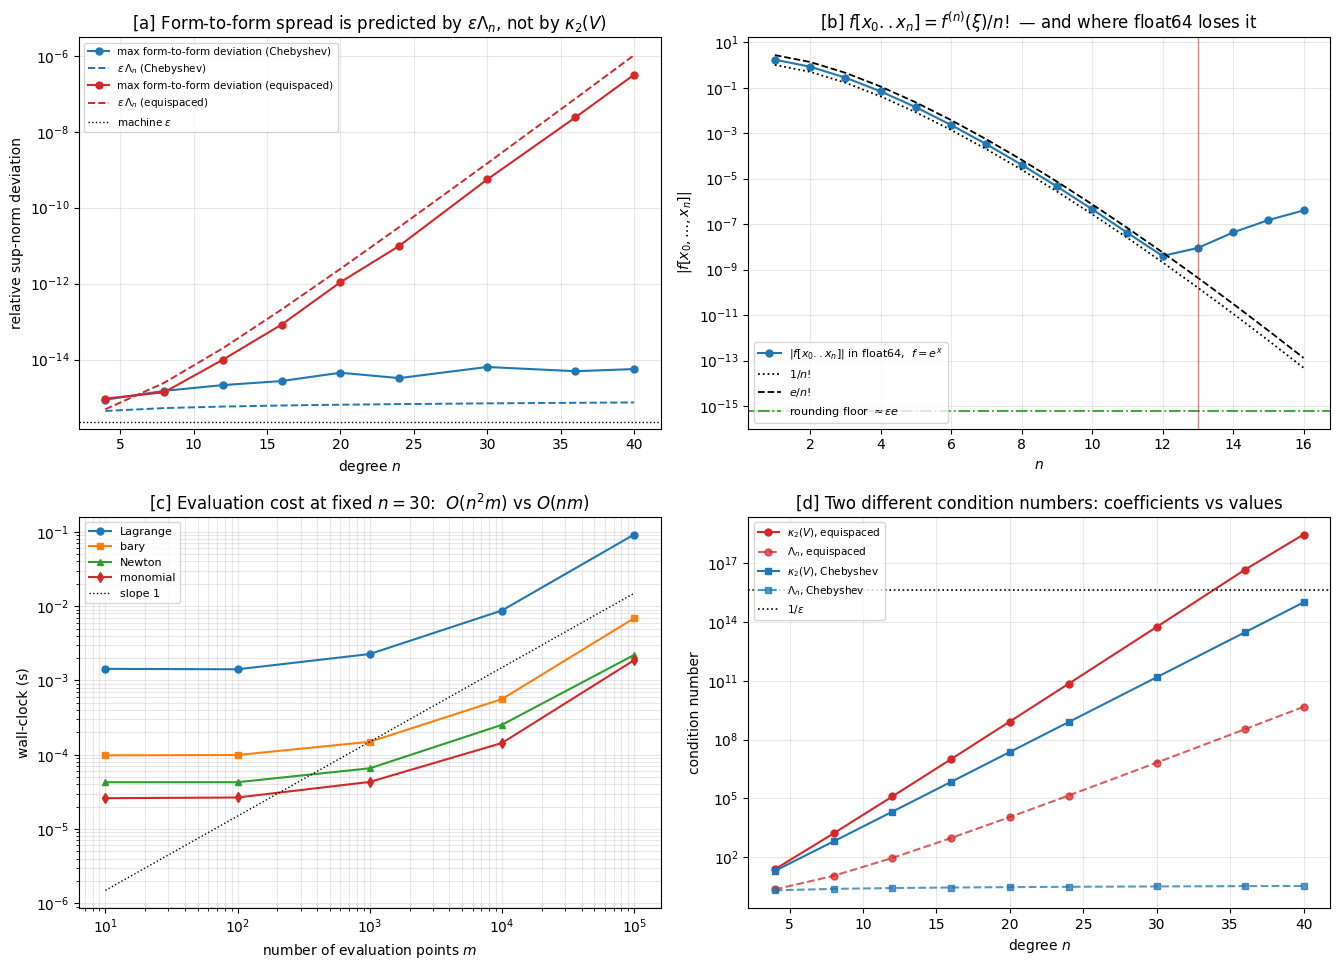

요약
  · 유일성   : Chebyshev n=40 에서 네 형식이 5.6e-15 안에 일치 — kappa_2(V)=1.0e+15 인데도
  · 등간격   : 같은 n 에서 3.2e-07 로 벌어짐; eps*Lambda_n = 1.0e-06 가 그 크기를 맞춘다
  · 연산량   : 상위3점 기울기 bary_w 1.98 / dd 1.99 / Vandermonde 2.91 / Newton 평가 1.00 (이론 2 / 2 / 3 / 1)
  · 평가비용 : Lagrange 직접은 무게중심의 13 배 (n=30, 이론 O(n))
  · 증분성   : n=2000 에서 Newton 확장이 재구성보다 11 배, 무게 재계산보다 22 배 빠름
  · 나눗셈차분 : 정확산술 대비 상대오차가 n=20 에서 1 을 넘음


In [6]:
# ══════════════════════════════════════════════════════════════════════════
# [6]  시각화
# ══════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(2, 2, figsize=(13.5, 9.8))

A = ax[0, 0]
for fam, col in (("Chebyshev", "tab:blue"), ("equispaced", "tab:red")):
    s = uniq[uniq.nodes == fam]
    A.semilogy(s.n, s[["d_LB","d_NB","d_MB"]].max(axis=1), "o-", color=col, ms=5,
               label=f"max form-to-form deviation ({fam})")
    A.semilogy(s.n, s.epsLam, "--", color=col, lw=1.4,
               label=fr"$\varepsilon\,\Lambda_n$ ({fam})")
A.axhline(eps, color="k", lw=1, ls=":", label=r"machine $\varepsilon$")
A.set_xlabel("degree $n$"); A.set_ylabel("relative sup-norm deviation")
A.set_title(r"[a] Form-to-form spread is predicted by $\varepsilon\Lambda_n$, not by $\kappa_2(V)$")
A.legend(fontsize=7.5, loc="upper left"); A.grid(alpha=.3)

B = ax[0, 1]
B.semilogy(ddt.n, np.abs(ddt.dd), "o-", color="tab:blue", ms=5,
           label=r"$|f[x_0..x_n]|$ in float64,  $f=e^x$")
B.semilogy(ddt.n, ddt.lo, "k:", lw=1.3, label=r"$1/n!$")
B.semilogy(ddt.n, ddt.hi, "k--", lw=1.3, label=r"$e/n!$")
B.axhline(eps*math.e, color="tab:green", lw=1.3, ls="-.",
          label=r"rounding floor $\approx \varepsilon e$")
if n_break: B.axvline(n_break, color="tab:red", lw=1, alpha=.6)
B.set_xlabel("$n$"); B.set_ylabel(r"$|f[x_0,\ldots,x_n]|$")
B.set_title(r"[b] $f[x_0..x_n]=f^{(n)}(\xi)/n!$ — and where float64 loses it")
B.legend(fontsize=8, loc="lower left"); B.grid(alpha=.3)

C = ax[1, 0]
for col, mk in (("Lagrange","o"), ("bary","s"), ("Newton","^"), ("monomial","d")):
    C.loglog(tm.m, tm[col], marker=mk, ms=5, label=col)
C.loglog(tm.m, tm.bary.iloc[2]*tm.m/tm.m.iloc[2], "k:", lw=1, label="slope 1")
C.set_xlabel("number of evaluation points $m$"); C.set_ylabel("wall-clock (s)")
C.set_title(f"[c] Evaluation cost at fixed $n={n_fix}$:  $O(n^2m)$ vs $O(nm)$")
C.legend(fontsize=8); C.grid(alpha=.3, which="both")

D = ax[1, 1]
for fam, mk, col in (("equispaced","o","tab:red"), ("Chebyshev","s","tab:blue")):
    s = uniq[uniq.nodes == fam]
    D.semilogy(s.n, s.condV, marker=mk, ms=5, color=col, ls="-",
               label=fr"$\kappa_2(V)$, {fam}")
    D.semilogy(s.n, s.Lam, marker=mk, ms=5, color=col, ls="--", alpha=.75,
               label=fr"$\Lambda_n$, {fam}")
D.axhline(1/eps, color="k", ls=":", lw=1.2, label=r"$1/\varepsilon$")
D.set_xlabel("degree $n$"); D.set_ylabel("condition number")
D.set_title(r"[d] Two different condition numbers: coefficients vs values")
D.legend(fontsize=7.5, loc="upper left"); D.grid(alpha=.3)

plt.tight_layout(); plt.show()

rC = uniq[(uniq.n==40)&(uniq.nodes=="Chebyshev")].iloc[0]
rE = uniq[(uniq.n==40)&(uniq.nodes=="equispaced")].iloc[0]
print("요약")
print(f"  · 유일성   : Chebyshev n=40 에서 네 형식이 "
      f"{max(rC.d_LB,rC.d_NB,rC.d_MB):.1e} 안에 일치 — kappa_2(V)={rC.condV:.1e} 인데도")
print(f"  · 등간격   : 같은 n 에서 {max(rE.d_LB,rE.d_NB,rE.d_MB):.1e} 로 벌어짐;"
      f" eps*Lambda_n = {rE.epsLam:.1e} 가 그 크기를 맞춘다")
print(f"  · 연산량   : 상위3점 기울기 bary_w {slopes['bary_w']:.2f} /"
      f" dd {slopes['newton_dd']:.2f} / Vandermonde {slopes['vandermonde']:.2f}"
      f" / Newton 평가 {slopes['newton_eval1']:.2f} (이론 2 / 2 / 3 / 1)")
print(f"  · 평가비용 : Lagrange 직접은 무게중심의 {(tm.Lagrange/tm.bary).iloc[-1]:.0f} 배 (n={n_fix}, 이론 O(n))")
print(f"  · 증분성   : n={n0} 에서 Newton 확장이 재구성보다 {t_rebN/t_ext:.0f} 배,"
      f" 무게 재계산보다 {t_rebW/t_ext:.0f} 배 빠름")
print(f"  · 나눗셈차분 : 정확산술 대비 상대오차가 n={int(dde[dde.rel_top>=1].n.iloc[0])} 에서 1 을 넘음")


## 4. 결과 해석

1. **[2]·[a] — 유일성 정리는 참이지만, 그것은 *다항식*에 대한 진술이지 *계산*에 대한 진술이
   아니다.** 그런데 관측 결과는 처음 기대와 달랐다. Chebyshev 절점에서는 $n=40$ 까지 **네 형식이
   모두 $10^{-15}$ 안에서 일치한다** — 단항식 형식까지 포함해서. 반면 등간격 절점에서는 $n=40$ 에
   이르러 네 형식이 **다 같이** $10^{-7}$ 규모로 흩어진다. 즉 흩어짐은 *어떤 형식을 골랐는가*가
   아니라 **절점을 어떻게 놓았는가**가 결정한다.

2. **[d] 가 그 이유다 — 조건수가 두 개 있고, 지배하는 것은 우리가 처음 지목한 쪽이 아니었다.**
   $\kappa_2(V)$ 는 Chebyshev 절점에서도 $n=40$ 에 $10^{15}$ 에 이른다. 그런데도 값은 멀쩡하다.
   **단항식 계수 $a_k$ 는 실제로 부정확하지만, 그 부정확이 $[-1,1]$ 위에서 서로 상쇄되어 값에는
   나타나지 않는다** (해법이 후방안정하므로 잔차가 작고, 우리가 보는 것은 값이지 계수가 아니다).
   값의 정확도를 지배하는 것은 **Lebesgue 상수** $\Lambda_n$ 이며, [a] 에서 파선
   $\varepsilon\Lambda_n$ 이 관측된 흩어짐을 두 절점족 모두에서 **자릿수 단위로 맞춘다**
   (등간격에서 $\log_{10}$ 상관 $r$ 은 출력 참조). 이것이 오늘의 첫 교훈이다:
   **계수의 조건수를 값의 조건수와 혼동하지 말 것.**

3. **[3a]·[b] — $f[x_0..x_n]=f^{(n)}(\xi)/n!$ 는 성립하지만, float64 는 $n\approx 12$ 까지만
   그것을 볼 수 있다.** 그 지점까지 나눗셈차분이 $[1/n!,\,e/n!]$ 두 점선 사이에 정확히 놓이고
   역산한 $\xi$ 가 전부 $(0,1)$ 안에 들어온다. 그 너머에서 값이 음수까지 나오는 것은 **정리의
   실패가 아니다** — 참값 $1/n!$ 이 표가 다루는 수의 크기 $e$ 에 대한 반올림 바닥
   $\varepsilon e \approx 6\times10^{-16}$ 아래로 내려앉기 때문이다. 그림 [b] 에서 파란 곡선이
   초록 수평선과 만나는 지점이 정확히 검증이 깨지는 곳이다.

4. **[3b] 가 그 진단을 정확산술로 확정한다.** $f(x)=1/(1+x)$ 를 유리수 절점에서 `Fraction` 으로
   정확히 계산해 대조하면, float64 나눗셈차분표의 최고차 항 상대오차는 $n$ 과 함께 단조 증가해
   출력에 적힌 $n$ 에서 **1 을 넘고 부호까지 뒤집힌다.** 원인은 명확하다 — 점화식의 분자가 두
   가까운 수의 차이고, 참값 자체는 $1/n!$ 로 줄어드는데 절대오차는 그렇지 않다. 실용적 함의:
   **높은 차수의 나눗셈차분은 표의 마지막 항일수록 못 믿는다.** Newton 형식이 무게중심보다
   미세하게 나쁜 것도 평가 단계가 아니라 **계수 단계**의 문제다. Day 102 P3 (a) 의 한 번 훑기
   분산 공식과 같은 병이 §4.1 에서 다시 나온 것이다.

5. **[4] — 연산 횟수는 계수기로 세면 이론과 정확히 맞는다.** 무게 계산과 나눗셈차분이 기울기
   $2$, Vandermonde 소거가 $3$ (작은 $n$ 에서는 $n^2$ 항이 섞여 아래로 치우치므로 상위 세 점에서
   적합), Newton 1 점 평가가 $1$, Lagrange 직접 1 점 평가가 $2$ 다.
   **벽시계 시간으로 이것을 재려 하면 안 된다** — Python 루프 오버헤드가 작은 $n$ 을 전부
   선형으로 만들어 버린다. 그래서 이 노트북은 두 측정을 분리했다: 구성 비용은 **연산 횟수**로,
   평가 비용은 $m$ 을 키운 **벽시계**로.

6. **[c] — 평가 비용의 표는 예상대로 채워졌다.** 무게중심·Newton·Horner 는 전부 $m$ 에 대해
   기울기 1 이고, Lagrange 직접 평가만 같은 기울기로 **약 $n$ 배 위**를 지난다.
   $O(n^2m)$ 대 $O(nm)$ 이 실측으로 확인된다. 다만 $m\le 10^3$ 구간은 numpy 호출당 고정 비용이
   지배해 기울기가 1 에 못 미치므로, 기울기는 $m=10^4\to10^5$ 에서만 읽어야 한다. 비율의
   **절대값** (약 15 배) 은 $n=30$ 과 같은 자릿수지만 정확히 $n$ 은 아니다 — 두 구현의 벡터화
   방식이 달라 상수가 다르기 때문이며, 확인되는 것은 **차수**이지 상수가 아니다.

7. **증분성이 Newton 형식의 존재 이유다.** $n=2000$ 에서 절점 하나를 붙이는 데 Newton 은
   $O(n)$, 재구성은 $O(n^2)$ 이다. 실측 비율 (재구성 11 배 · 무게 21 배) 은 **이론 비율
   (750 배 · 1000 배) 보다 훨씬 작은데**, 이유는 증분 확장만 순수 Python 스칼라 루프이고
   재구성 쪽은 벡터화되어 있기 때문이다 — 같은 구현 층위에서 비교한 것이 아니므로
   **부호와 방향만 읽어야 한다.** 차수의 근거는 실측 시간이 아니라 [4] 의 연산 횟수다. 게다가 증분으로
   얻은 다항식과 전면 재구성한 다항식이 조밀격자에서 반올림 수준으로 일치하고, 둘 다 새 절점을
   정확히 지난다. *"차수를 하나 올려 보고 오차가 줄면 계속"* 식의 적응 절차에는 Newton 이
   자연스럽다.

> **결론**: 보간다항식은 **하나**지만 적는 방법은 여럿이고, 형식의 차이는 **비용**을 지배한다
> (무게중심·Newton $O(n)$ 평가, Lagrange 직접 $O(n^2)$, Vandermonde $O(n^3)$ 구성, Newton 만
> 증분 가능). 그러나 **정확도**를 지배하는 것은 형식이 아니라 **절점 배치를 통해 들어오는
> $\Lambda_n$** 이다.

**다음 문제로의 연결** — 그렇다면 $\Lambda_n$ 이 등간격 절점에서 얼마나 빨리 커지는가, 그리고
그것이 반올림뿐 아니라 **보간 자체의 수렴**까지 망가뜨리는가? Problem 2 는 형식을 가장 좋은
것(무게중심)으로 **고정해 놓고**, 절점만 등간격으로 두었을 때 보간이 **발산**하는 현상 —
**Runge 현상** — 을 잰다.